# This demo shows how to preprocess data (outlier detection and data imputation) and obtain valid data.


In [1]:
import matplotlib.pyplot as plt
from matplotlib.pylab import mpl
import numpy as np
import pandas as pd
import seaborn as sns

from Influxdb_API.Influxdb_API import ClientInfluxdb
import preprocess

## 1. Get orignal data 

1.1 Get original data and organize it

In [2]:
# get data by influxdb_API, please refer to it.
start_time = '2022-06-22 00:00:00'
end_time = '2022-10-01 00:00:00'
vrf_id = 'vrf_0000CC311178CCM262323410008787JG'
power_vrf_id = 'mDev_EMeter_Roof_MDV_7'
num_indoor = [0, 1, 2]
data_point = preprocess.data_point(vrf_id=vrf_id, power_vrf_id=power_vrf_id, num_indoor=num_indoor)
data = preprocess.get_data(data_point, start_time, end_time, rsp_time='15 min')

# differentiate the meter data
data['Qin'] = data['Qin'].diff()
data['Pvrf'] = data['Pvrf'].diff()
data['Pvrf_sys'] = data['Pvrf_sys'].diff()
# unified units into KW, convenient to plot
data['Qin'] = data['Qin'] / 0.25
data['Pvrf'] = data['Pvrf'] / 0.25
data['Pvrf_sys'] = data['Pvrf_sys'] / 0.25
data['Qs'] = data['Qs'] / 1000
data['Qac'] = data['Qac'] / 1000
data['Qac_sys'] = data['Qac_sys'] / 1000
for indoor_num in num_indoor:
    data[f'Qac{indoor_num}'] = data[f'Qac{indoor_num}'] / 1000

# calculate average temperature
data['Ti'] = data.filter(like='Ti').mean(axis=1)

# merge
data['Pvrf'] = data.apply(lambda row: row['Pvrf'] if pd.notnull(row['Pvrf']) else row['Pvrf_sys'], axis=1)
data['Qac'] = data.apply(lambda row: row['Qac'] if pd.notnull(row['Qac']) else row['Qac_sys'], axis=1)

# organize
order = ['Ti', 'Ta', 'Qs', 'Qin', 'Qac', 'Pvrf']
for indoor_num in num_indoor:
    order.append(f'Ti{indoor_num}')
    order.append(f'Sc{indoor_num}')
    order.append(f'Qac{indoor_num}')
data = data[order]

print(data.shape)
data


(9697, 15)


,Ti,Ta,Qs,Qin,Qac,Pvrf,Ti0,Sc0,Qac0,Ti1,Sc1,Qac1,Ti2,Sc2,Qac2
2022-06-22 00:00:00,30.531373,28.600000,0.0,NaN,0.0,NaN,31.3000,0.0,0.0,30.505882,0.0,0.0,29.788235,0.0,0.0
2022-06-22 00:15:00,30.501852,28.566667,0.0,7.32,0.0,0.000000e+00,31.3000,0.0,0.0,30.500000,0.0,0.0,29.705556,0.0,0.0
2022-06-22 00:30:00,30.503704,28.466667,0.0,6.56,0.0,4.000000e-02,31.3000,0.0,0.0,30.500000,0.0,0.0,29.711111,0.0,0.0
2022-06-22 00:45:00,30.500000,28.400000,0.0,4.60,0.0,0.000000e+00,31.3000,0.0,0.0,30.500000,0.0,0.0,29.700000,0.0,0.0
2022-06-22 01:00:00,30.529412,28.400000,0.0,4.88,0.0,0.000000e+00,31.3000,0.0,0.0,30.588235,0.0,0.0,29.700000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-09-30 23:00:00,30.970833,NaN,NaN,NaN,0.0,0.000000e+00,30.7125,0.0,NaN,31.700000,0.0,NaN,30.500000,0.0,NaN
2022-09-30 23:15:00,31.020000,NaN,NaN,NaN,0.0,-9.094947e-13,30.8000,0.0,NaN,31.700000,0.0,NaN,30.560000,0.0,NaN
2022-09-30 23:30:00,31.033333,NaN,NaN,NaN,0.0,9.094947e-13,30.8000,0.0,NaN,31.700000,0.0,NaN,30.600000,0.0,NaN
2022-09-30 23:45:00,31.070000,NaN,NaN,NaN,0.0,-9.094947e-13,30.8300,0.0,NaN,31.710000,0.0,NaN,30.670000,0.0,NaN


1.2 Show original data

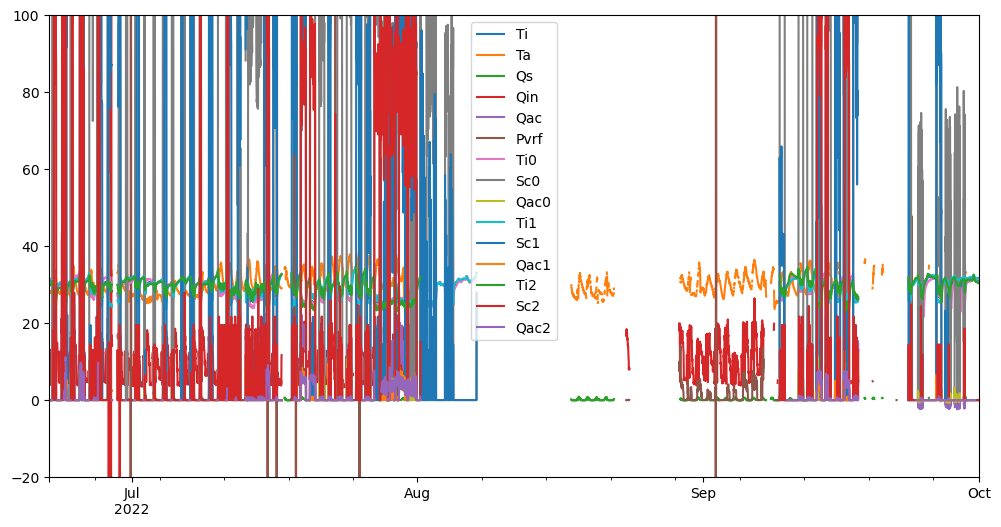

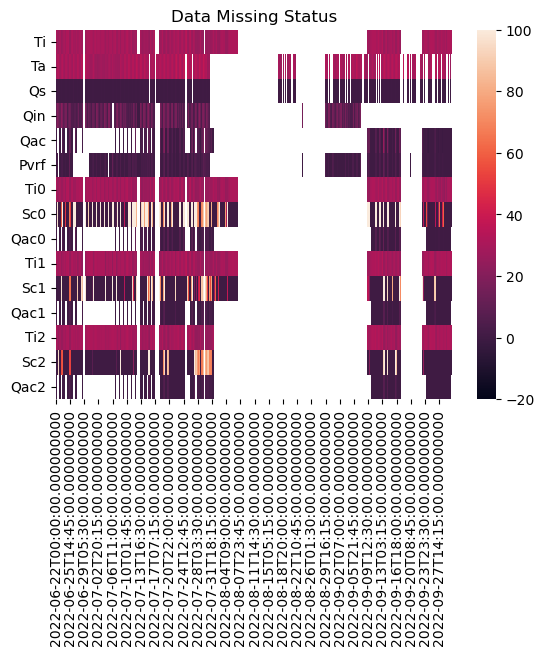

In [3]:
data.plot(figsize=(12,6))
plt.ylim(-20, 100)
plt.show()

sns.heatmap(data.T, vmin=-20, vmax=100)
plt.title('Data Missing Status')
plt.show()

## 2. Preprocess data

2.1 Set preprocessing parameters

In [4]:
# Value is the data type, currently we support the following types {'T_amb', 'T_sys', 'Sys', 'Meter', 'Other'}.
column_type = {
    'Ti': 'T_amb',
    'Ta': 'T_amb',
    'Qs': 'Other',
    'Qin': 'Meter',
    'Qac': 'Other',
    'Pvrf': 'Meter',
}
# The reasonable physical range of data for each column.
data_range = {
    'Ti': (-10, 50),
    'Ta': (-10, 50),
    'Qs': (0, 100),
    'Qin': (0, 100),
    'Qac': (0, 100),
    'Pvrf': (0, 200),
}
# Data missing that is larger than the linear_time_delta will not be imputed.
linear_time_delta = {
    'Ti': '4 hours',
    'Ta': '4 hours',
    'Qs': '1 hours',
    'Qin': '4 hours',
    'Qac': '0.5 hours',
    'Pvrf': '0.5 hours',
}

for indoor_num in num_indoor:
    column_type[f'Ti{indoor_num}'] = 'T_amb'
    column_type[f'Qac{indoor_num}'] = 'Other'
    column_type[f'Sc{indoor_num}'] = 'Other'
    data_range[f'Ti{indoor_num}'] = (-10, 50)
    data_range[f'Qac{indoor_num}'] = (0, 100)
    data_range[f'Sc{indoor_num}'] = (0, 400)
    linear_time_delta[f'Ti{indoor_num}'] = '4 hours'
    linear_time_delta[f'Qac{indoor_num}'] = '0.5 hours'
    linear_time_delta[f'Sc{indoor_num}'] = '0.5 hours'

params = {
    # common parameters
    'sampling_time': pd.Timedelta('15 min'),
    'sampling_rate': 4,   # 4 times per hour, depends on sampling_time.

    # parameters of outlier detection
    'kd_bandwidth': 1.0,
    'kd_ratio': 0.01,
    'abrupt_win_size': 5,
    'abrupt_thresh': 2.5,

    # parameters of data imputation
    'linear_time_delta': linear_time_delta,   # data missing for more than consecutive linear_time_delta will not be linear imputation.

    # parameters of obtain valid data (by calculating missing rate)
    'ms_thresh': 0.0,   # the condition of missing rate (< ms_thresh) for multiple data.
    'mode': 'closest',   # 'closest'(time first), 'longset'(data length first).
    'interval_min_day': 3,   # minimum number of days needed for training.
    'interval_max_day': 14,   # maximum number of days needed for training.
}

2.1 Data preprocessing

Ti: 58 outliers
Ta: 61 outliers
Qs: 61 outliers
Qin: 107 outliers
Qac: 167 outliers
Pvrf: 148 outliers
Ti0: 59 outliers
Sc0: 58 outliers
Qac0: 87 outliers
Ti1: 61 outliers
Sc1: 58 outliers
Qac1: 40 outliers
Ti2: 53 outliers
Sc2: 52 outliers
Qac2: 36 outliers


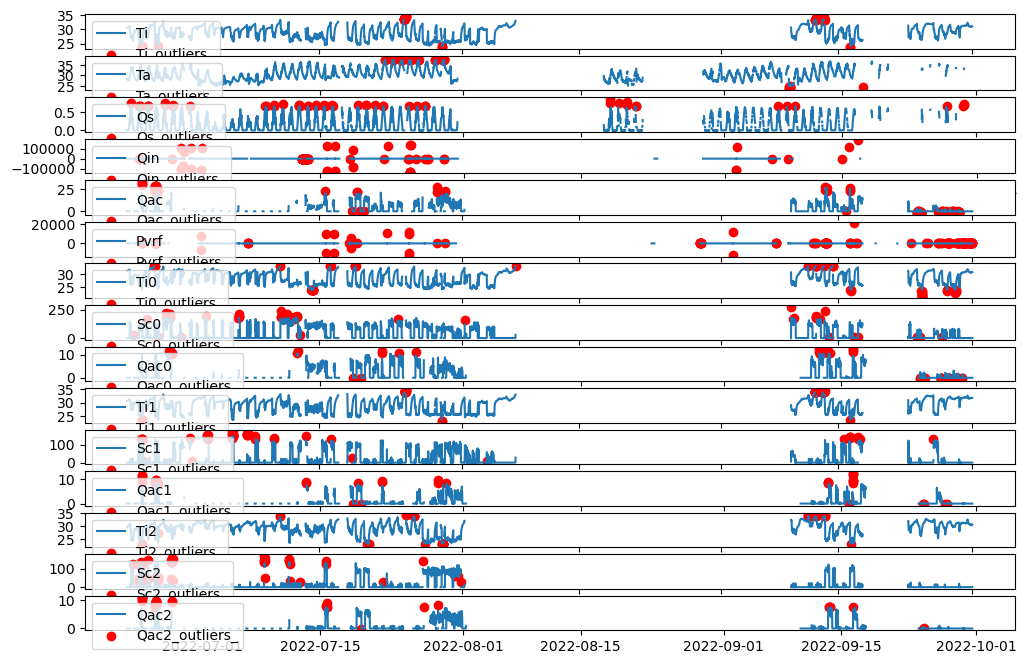

In [5]:
# initialize a DataPreprocess class
# after process, then we will have self.data(original data), self.data_impute(data imputed), 
# self.data_rmol(data removed outliers), self.data_rmol_impute(data removed outliers and imputed)
pre = preprocess.DataPreprocess(data=data, column_type=column_type, data_range=data_range, **params)
pre.process()

# plot outliers
preprocess.od_plot(pre.data, pre.data_rmol, pre.outlier_indexes)

## 3. Obtain valid data by calculating missing rate range(interval_max_day, interval_min_day) days backward at each sampling point

3.1 valid_data()

if mode=='closest':
    return valid data closest to the current time try to meet ms_thresh and interval_min_day.

if mode=='longest':
    return valid data longest try to meet ms_thresh and interval_max_day.

Ti origin_impute, the closest optimal moment to the present:  2022-09-29 15:00:00 (minimum missing rate: 0.0) 
------------------
Ta origin_impute, the closest optimal moment to the present:  2022-09-30 13:15:00 (minimum missing rate: 0.0) 
------------------
Qs origin_impute, the closest optimal moment to the present:  2022-09-29 13:45:00 (minimum missing rate: 0.0) 
------------------
Qin origin_impute, the closest optimal moment to the present:  2022-09-07 14:00:00 (minimum missing rate: 0.0) 
------------------
Qac origin_impute, the closest optimal moment to the present:  2022-09-29 15:15:00 (minimum missing rate: 0.0) 
------------------
Pvrf origin_impute, the closest optimal moment to the present:  2022-09-29 15:15:00 (minimum missing rate: 0.0) 
------------------
Ti0 origin_impute, the closest optimal moment to the present:  2022-09-29 15:00:00 (minimum missing rate: 0.0) 
------------------
Sc0 origin_impute, the closest optimal moment to the present:  2022-09-29 15:00:00 (m

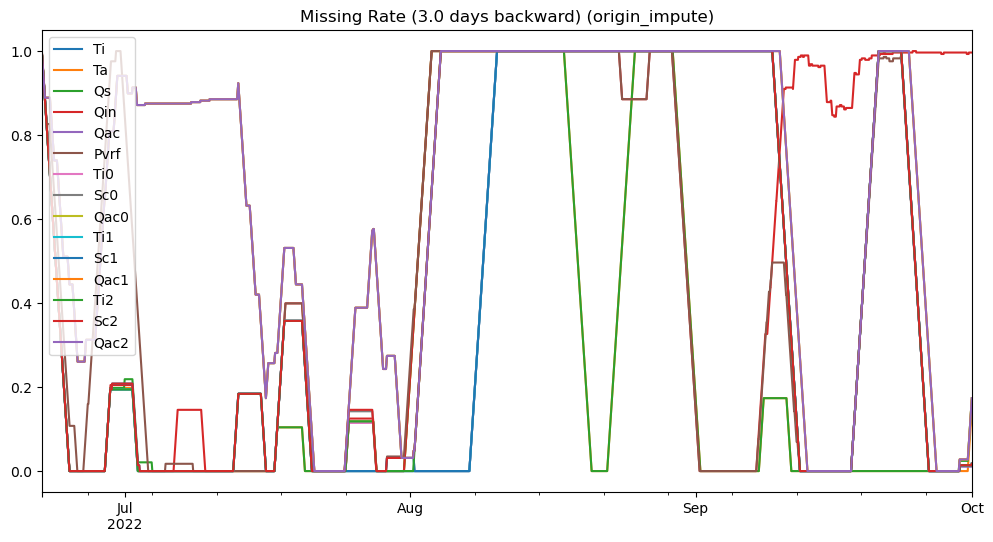

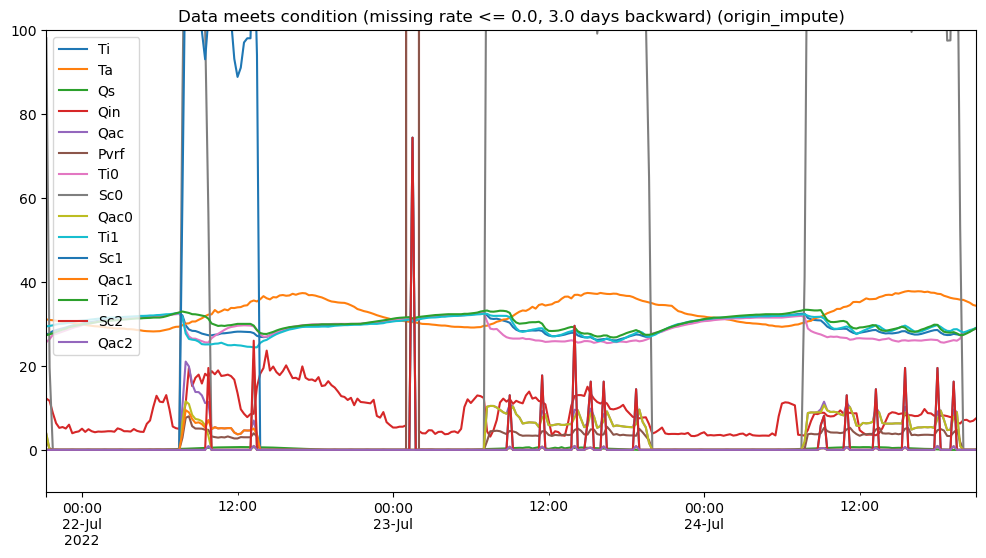

Ti rmol_impute, the closest optimal moment to the present:  2022-09-29 15:00:00 (minimum missing rate: 0.0) 
------------------
Ta rmol_impute, the closest optimal moment to the present:  2022-09-30 13:15:00 (minimum missing rate: 0.0) 
------------------
Qs rmol_impute, the closest optimal moment to the present:  2022-09-29 13:45:00 (minimum missing rate: 0.0) 
------------------
Qin rmol_impute, the closest optimal moment to the present:  2022-09-07 14:00:00 (minimum missing rate: 0.0) 
------------------
Qac rmol_impute, the closest optimal moment to the present:  2022-09-29 15:15:00 (minimum missing rate: 0.0) 
------------------
Pvrf rmol_impute, the closest optimal moment to the present:  2022-09-29 15:15:00 (minimum missing rate: 0.0) 
------------------
Ti0 rmol_impute, the closest optimal moment to the present:  2022-09-29 15:00:00 (minimum missing rate: 0.0) 
------------------
Sc0 rmol_impute, the closest optimal moment to the present:  2022-09-29 15:00:00 (minimum missing r

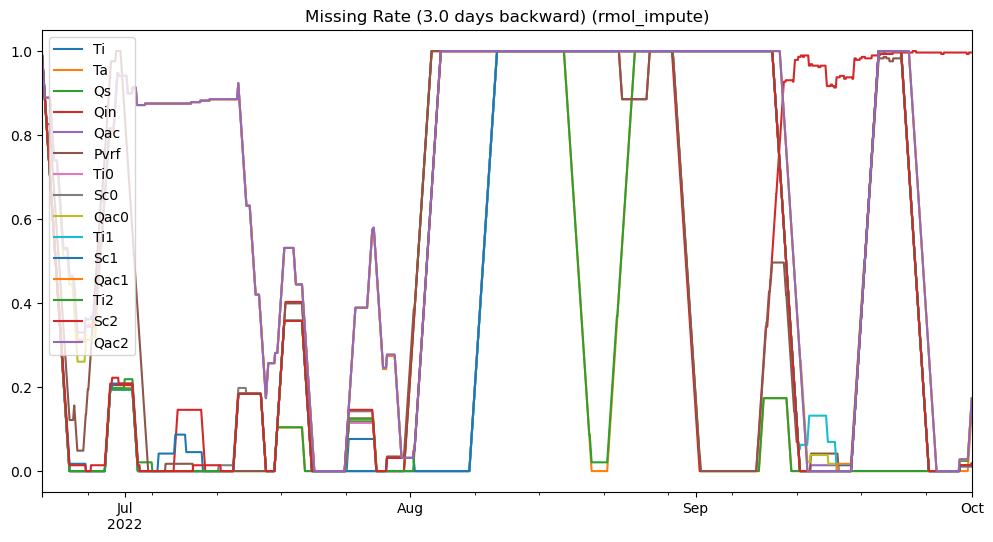

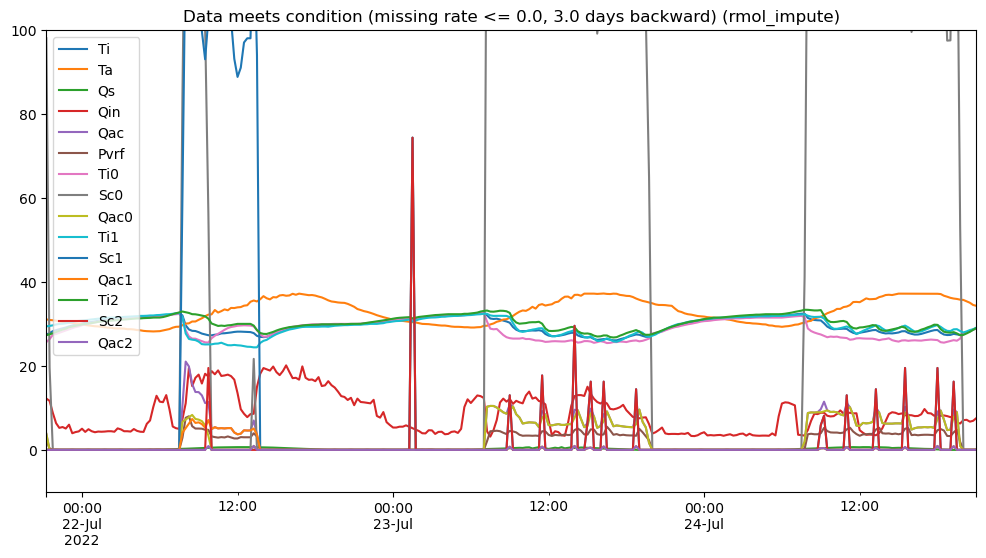

In [6]:
data_valid_impute = preprocess.valid_data(pre.data_impute, label='origin_impute', plot=True, **params)
data_valid_rmol_impute = preprocess.valid_data(pre.data_rmol_impute, label='rmol_impute', plot=True, **params)

3.2 valid_data2()

Return all data fragments that meets the interval_min_day and ms_thresh requirement.


In [7]:
data_valid_impute_list = preprocess.valid_data2(pre.data_impute, label='origin_impute', plot=True, **params)
data_valid_rmol_impute_list = preprocess.valid_data2(pre.data_rmol_impute, label='rmol_impute', plot=True, **params)